<a href="https://colab.research.google.com/github/nahaas27/Adapting-T5-for-Medical-QA-on-MedQuAD-A-Comparison-of-Baseline-Full-Fine-Tuning-LoRA./blob/main/Task1_Qualitative_FFT_LoRA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1 — MedQuAD QA



In [1]:
!pip install -q datasets transformers accelerate peft evaluate rouge_score

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.7 MB/s eta 0:00:00


In [2]:
import torch, gc, numpy as np, pandas as pd
from datasets import load_dataset, disable_caching
from transformers import AutoTokenizer, T5ForConditionalGeneration, TrainingArguments, Trainer, DataCollatorForSeq2Seq
from peft import LoraConfig, get_peft_model
import evaluate
import matplotlib.pyplot as plt

disable_caching()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## Load + HARD filter invalid answers

In [3]:
raw = load_dataset("lavita/MedQuAD", split="train").shuffle(seed=42).select(range(4000))

def clean_text(x):
    if x is None:
        return ""
    if isinstance(x, (list, tuple)):
        x = " ".join([str(i) for i in x if i is not None])
    x = str(x).strip()
    # normalize
    if x.lower() in {"none", "null", "nan"}:
        return ""
    return x

def is_valid(example):
    q = clean_text(example.get("question"))
    a = clean_text(example.get("answer"))
    return (len(q) > 0) and (len(a) > 0)

filtered = raw.filter(is_valid)

print("Raw subset size:", len(raw))
print("Filtered valid QA size:", len(filtered))

train_test = filtered.train_test_split(test_size=0.2, seed=42)
test_valid = train_test["test"].train_test_split(test_size=0.5, seed=42)

train_dataset = train_test["train"]
val_dataset = test_valid["train"]
test_dataset = test_valid["test"]

print("Train/Val/Test:", len(train_dataset), len(val_dataset), len(test_dataset))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-e36383d177026d(…):   0%|          | 0.00/10.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/47441 [00:00<?, ? examples/s]

Filter:   0%|          | 0/4000 [00:00<?, ? examples/s]

Raw subset size: 4000
Filtered valid QA size: 1359
Train/Val/Test: 1087 136 136


## Sanity checks

In [4]:
def count_invalid(ds):
    bad = 0
    for ex in ds:
        if len(clean_text(ex["answer"])) == 0:
            bad += 1
    return bad

print("Invalid answers in train:", count_invalid(train_dataset))
print("Invalid answers in val:", count_invalid(val_dataset))
print("Invalid answers in test:", count_invalid(test_dataset))

assert count_invalid(test_dataset) == 0, "Test still has invalid answers — filtering failed!"


Invalid answers in train: 0
Invalid answers in val: 0
Invalid answers in test: 0


## Tokenizer + preprocessing

In [5]:
model_name = "t5-base"   # if you hit OOM, change to "t5-small"
tokenizer = AutoTokenizer.from_pretrained(model_name)

MAX_SOURCE_LEN = 128
MAX_TARGET_LEN = 128

def preprocess_function(examples):
    questions = [clean_text(q) for q in examples["question"]]
    answers   = [clean_text(a) for a in examples["answer"]]

    inputs = ["question: " + q for q in questions]
    model_inputs = tokenizer(inputs, max_length=MAX_SOURCE_LEN, truncation=True)

    labels = tokenizer(text_target=answers, max_length=MAX_TARGET_LEN, truncation=True)
    label_ids = labels["input_ids"]
    label_ids = [[(t if t != tokenizer.pad_token_id else -100) for t in seq] for seq in label_ids]
    model_inputs["labels"] = label_ids
    return model_inputs


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

In [6]:
train_tokenized = train_dataset.map(preprocess_function, batched=True, remove_columns=train_dataset.column_names)
val_tokenized   = val_dataset.map(preprocess_function, batched=True, remove_columns=val_dataset.column_names)
test_tokenized  = test_dataset.map(preprocess_function, batched=True, remove_columns=test_dataset.column_names)

data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, padding=True)
rouge = evaluate.load("rouge")


Map:   0%|          | 0/1087 [00:00<?, ? examples/s]

Map:   0%|          | 0/136 [00:00<?, ? examples/s]

Map:   0%|          | 0/136 [00:00<?, ? examples/s]

In [7]:
GEN_KWARGS = dict(
    num_beams=4,
    max_new_tokens=220,
    early_stopping=True,
    no_repeat_ngram_size=3,
    repetition_penalty=1.15,
    length_penalty=1.0
)

def generate_text(model, question):
    inp = tokenizer("question: " + question, return_tensors="pt", truncation=True, max_length=MAX_SOURCE_LEN).to(device)
    with torch.no_grad():
        out = model.generate(**inp, **GEN_KWARGS)
    return tokenizer.decode(out[0], skip_special_tokens=True).strip()


## Manual ROUGE eval

In [8]:
def eval_rouge_manual(model, tokenized_ds, n=200):
    model.eval()
    subset = tokenized_ds.select(range(min(n, len(tokenized_ds))))
    preds, refs = [], []
    for ex in subset:
        input_ids = torch.tensor(ex["input_ids"]).unsqueeze(0).to(device)
        attn      = torch.tensor(ex["attention_mask"]).unsqueeze(0).to(device)

        with torch.no_grad():
            out = model.generate(
                input_ids=input_ids,
                attention_mask=attn,
                **GEN_KWARGS
            )

        pred = tokenizer.decode(out[0], skip_special_tokens=True).strip()
        ref_ids = [t for t in ex["labels"] if t != -100]
        ref = tokenizer.decode(ref_ids, skip_special_tokens=True).strip()

        preds.append(pred)
        refs.append(ref)

    res = rouge.compute(predictions=preds, references=refs)
    return {k: float(v) for k, v in res.items()}


## Baseline evaluation (no training)

In [9]:
torch.cuda.empty_cache(); gc.collect()
baseline_model = T5ForConditionalGeneration.from_pretrained(model_name).to(device)

baseline_results = eval_rouge_manual(baseline_model, test_tokenized, n=200)
print("Baseline ROUGE:", baseline_results)

del baseline_model
torch.cuda.empty_cache(); gc.collect()


model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Baseline ROUGE: {'rouge1': 0.03040221464749736, 'rouge2': 0.013646856461804184, 'rougeL': 0.029618861154812628, 'rougeLsum': 0.02943459656650095}


0

##  Full Fine-Tuning (FFT)

In [10]:
torch.cuda.empty_cache(); gc.collect()
fft_model = T5ForConditionalGeneration.from_pretrained(model_name).to(device)

fft_args = TrainingArguments(
    output_dir="./t5_fft",
    eval_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    weight_decay=0.01,
    fp16=False,
    remove_unused_columns=True,
    report_to="none",
    logging_steps=50,
    save_strategy="epoch"
)

fft_trainer = Trainer(
    model=fft_model,
    args=fft_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    data_collator=data_collator
)

fft_trainer.train()


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss
1,10.906809,2.336959
2,9.785677,2.176093
3,9.384118,2.142933


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=408, training_loss=10.590924169503007, metrics={'train_runtime': 304.3764, 'train_samples_per_second': 10.714, 'train_steps_per_second': 1.34, 'total_flos': 82177202211840.0, 'train_loss': 10.590924169503007, 'epoch': 3.0})

In [11]:
fft_results = eval_rouge_manual(fft_model, test_tokenized, n=200)
print("FFT ROUGE:", fft_results)


FFT ROUGE: {'rouge1': 0.285972026330645, 'rouge2': 0.12294419460512587, 'rougeL': 0.21663321428786303, 'rougeLsum': 0.21710960352635045}


##  LoRA (PEFT)

In [12]:
torch.cuda.empty_cache(); gc.collect()

base_model = T5ForConditionalGeneration.from_pretrained(model_name)
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q", "v"]
)
peft_model = get_peft_model(base_model, lora_config).to(device)
peft_model.print_trainable_parameters()

lora_args = TrainingArguments(
    output_dir="./t5_lora",
    eval_strategy="epoch",
    learning_rate=3e-4,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    fp16=False,
    remove_unused_columns=True,
    report_to="none",
    logging_steps=50,
    save_strategy="epoch"
)

lora_trainer = Trainer(
    model=peft_model,
    args=lora_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    data_collator=data_collator
)

lora_trainer.train()


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

trainable params: 1,769,472 || all params: 224,673,024 || trainable%: 0.7876


Epoch,Training Loss,Validation Loss
1,11.228645,2.461759
2,10.301924,2.290113
3,9.869072,2.242235


TrainOutput(global_step=408, training_loss=11.07367779226864, metrics={'train_runtime': 255.6884, 'train_samples_per_second': 12.754, 'train_steps_per_second': 1.596, 'total_flos': 82910750985216.0, 'train_loss': 11.07367779226864, 'epoch': 3.0})

In [13]:
lora_results = eval_rouge_manual(peft_model, test_tokenized, n=200)
print("LoRA ROUGE:", lora_results)


LoRA ROUGE: {'rouge1': 0.25806064463505674, 'rouge2': 0.09850044753194426, 'rougeL': 0.19429381111362132, 'rougeLsum': 0.1944878029070427}


## Plot ROUGE comparison

,Baseline,FFT,LoRA
rouge1,0.030402,0.285972,0.258061
rouge2,0.013647,0.122944,0.098500
rougeL,0.029619,0.216633,0.194294


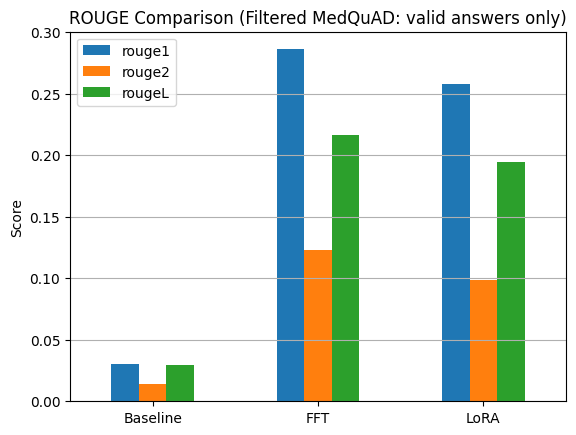

In [14]:
df = pd.DataFrame({
    "Baseline": baseline_results,
    "FFT": fft_results,
    "LoRA": lora_results
}).loc[["rouge1","rouge2","rougeL"]]

display(df)

df.T.plot(kind="bar")
plt.title("ROUGE Comparison (Filtered MedQuAD: valid answers only)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()


##  Loss curves

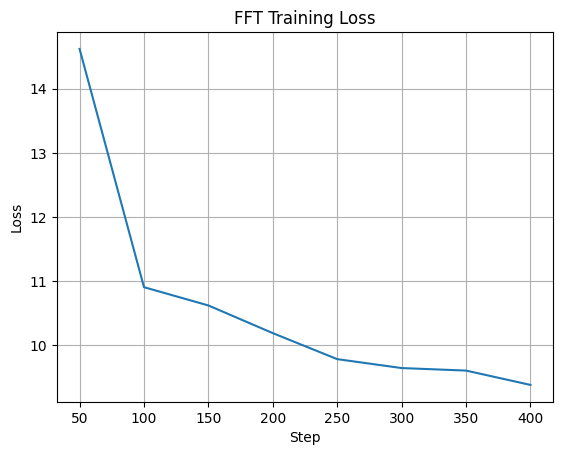

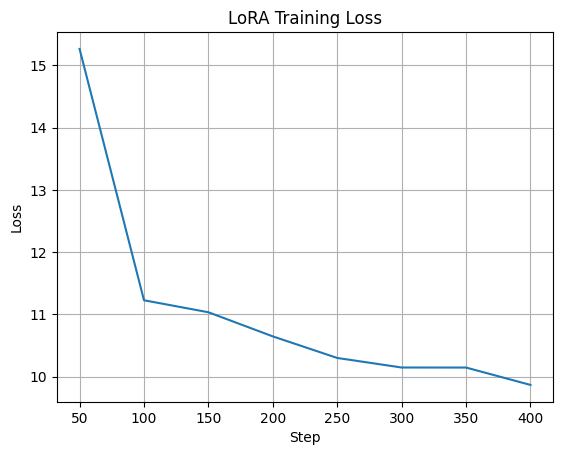

In [15]:
def plot_loss(trainer, title):
    logs = pd.DataFrame(trainer.state.log_history)
    if "loss" not in logs.columns:
        print(title, ": no loss logs")
        return
    loss = logs[logs["loss"].notna()]
    if len(loss) == 0:
        print(title, ": no loss values")
        return
    plt.figure()
    plt.plot(loss["step"], loss["loss"])
    plt.title(title)
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

plot_loss(fft_trainer, "FFT Training Loss")
plot_loss(lora_trainer, "LoRA Training Loss")


## Accurate qualitative analysis


In [16]:
def qualitative_block(num_examples=3):
    # Sample ONLY from filtered test_dataset with real answers
    samples = test_dataset.shuffle(seed=7).select(range(min(num_examples, len(test_dataset))))

    # Reload baseline for comparison (FFT & LoRA are in memory)
    base = T5ForConditionalGeneration.from_pretrained(model_name).to(device)
    base.eval()

    for i, ex in enumerate(samples):
        q = clean_text(ex["question"])
        ref = clean_text(ex["answer"])

        print("\n" + "="*95)
        print(f"Question {i+1}: {q}")
        print("\nReference Answer:\n", ref)

        print("\nBaseline Output:\n", generate_text(base, q))
        print("\nFFT Output:\n", generate_text(fft_model, q))
        print("\nLoRA Output:\n", generate_text(peft_model, q))

    del base
    torch.cuda.empty_cache(); gc.collect()

qualitative_block(num_examples=5)


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]


Question 1: How to diagnose Alzheimer's Disease ?

Reference Answer:
 An early, accurate diagnosis of Alzheimer's disease helps people and their families plan for the future. It gives them time to discuss care options, find support, and make legal and financial arrangements while the person with Alzheimers can still take part in making decisions. Also, even though no medicine or other treatment can stop or slow the disease, early diagnosis offers the best chance to treat the symptoms.

Baseline Output:
 diagnose

FFT Output:
 How to diagnose Alzheimer's Disease? The American Academy of Neurology provides the following information about the diagnosis and treatment of Alzheimer’s Disease. If the information is available, you can use the MedlinePlus Medical Dictionary to look up the definitions for these medical terms.

LoRA Output:
 How to diagnose Alzheimer's Disease?

Question 2: What are the genetic changes related to malignant hyperthermia ?

Reference Answer:
 Variations of the CAC